In [1]:
# IMPORT LIBRARIES

import os
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    auc,
    roc_auc_score,
    precision_score,
    recall_score,
    accuracy_score,
    f1_score
)

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# PROJECT PATHS

PROJECT_DIR = Path("/content/drive/MyDrive/skin_cancer_vs_Benign_tumor_cnn_model_personal")

DATASET_SPLIT = PROJECT_DIR / "dataset_split"
MODELS_DIR = PROJECT_DIR / "models"

IMAGE_HEIGHT = 128
IMAGE_WIDTH = 128
BATCH_SIZE = 32

print("Project Directory :", PROJECT_DIR)
print("Dataset Split     :", DATASET_SPLIT)
print("Models Directory  :", MODELS_DIR)

Project Directory : /content/drive/MyDrive/skin_cancer_vs_Benign_tumor_cnn_model_personal
Dataset Split     : /content/drive/MyDrive/skin_cancer_vs_Benign_tumor_cnn_model_personal/dataset_split
Models Directory  : /content/drive/MyDrive/skin_cancer_vs_Benign_tumor_cnn_model_personal/models


In [3]:
# LOAD TEST DATA

test_df = pd.read_csv(DATASET_SPLIT / "test.csv")

# Convert binary class_mode to string labels for Keras
test_df["binary_label_str"] = test_df["binary_label"].astype(str)

print("Test Images :", len(test_df))
print()

print(test_df["binary_label"].value_counts())

Test Images : 1505

binary_label
0    1217
1     288
Name: count, dtype: int64


In [4]:
# TEST DATA GENERATOR

eval_datagen = ImageDataGenerator(rescale=1./255)

test_generator = eval_datagen.flow_from_dataframe(
    dataframe=test_df,
    x_col="filepath",
    y_col="binary_label_str",
    directory=None,
    target_size=(IMAGE_HEIGHT, IMAGE_WIDTH),
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Test samples:", test_generator.samples)
print("Class indices:", test_generator.class_indices)

Found 1505 validated image filenames belonging to 2 classes.
Test samples: 1505
Class indices: {'0': 0, '1': 1}


In [5]:
# LOAD TRAINED MODEL

MODEL_PATH = MODELS_DIR / "custom_cnn_best.keras"

model = load_model(MODEL_PATH)

print("Model loaded successfully.")
print()
model.summary()

Model loaded successfully.



Model: "SkinCancer_CustomCNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 3,623,525 (13.82 MB)

 Trainable params: 1,207,201 (4.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

 Optimizer params: 2,414,404 (9.21 MB)

In [9]:
# EVALUATE MODEL

results = model.evaluate(test_generator, verbose=1)
print("Evaluation complete.")

48/48 ━━━━━━━━━━━━━━━━━━━━ 94s 2s/step - accuracy: 0.8040 - auc: 0.8593 - loss: 0.4079 - precision: 0.4914 - recall: 0.6910
Evaluation complete.


In [10]:
# PREDICTIONS GENERATION

# Reset generator to ensure prediction starts from first image
test_generator.reset()

y_prob = model.predict(test_generator, verbose=1)

y_prob = y_prob.flatten()

y_pred = (y_prob >= 0.5).astype(int)

y_true = test_df["binary_label"].values

print("Prediction complete.")
print("Total predictions:", len(y_pred))

48/48 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step
Prediction complete.
Total predictions: 1505


In [11]:
# PERFORMANCE METRICS

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
auc_score = roc_auc_score(y_true, y_prob)

print("=" * 25)
print("FINAL PERFORMANCE")
print("=" * 25)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUC      : {auc_score:.4f}")

FINAL PERFORMANCE
Accuracy : 0.8040
Precision: 0.4914
Recall   : 0.6910
F1 Score : 0.5743
AUC      : 0.8592


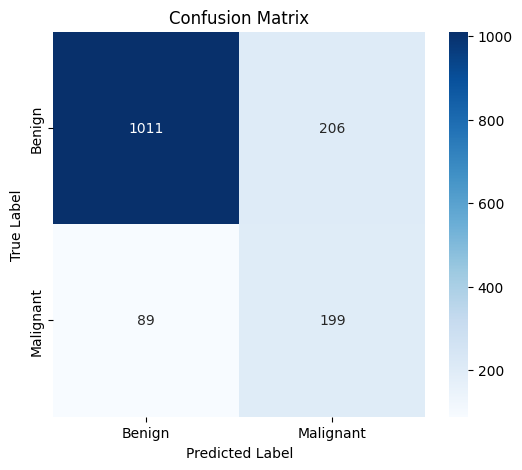

In [12]:
# CONFUSION MATRIX

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "Malignant"],
    yticklabels=["Benign", "Malignant"]
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [13]:
# CLASSIFICATION REPORT

report = classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malignant"]
)

print(report)

              precision    recall  f1-score   support

      Benign       0.92      0.83      0.87      1217
   Malignant       0.49      0.69      0.57       288

    accuracy                           0.80      1505
   macro avg       0.71      0.76      0.72      1505
weighted avg       0.84      0.80      0.82      1505



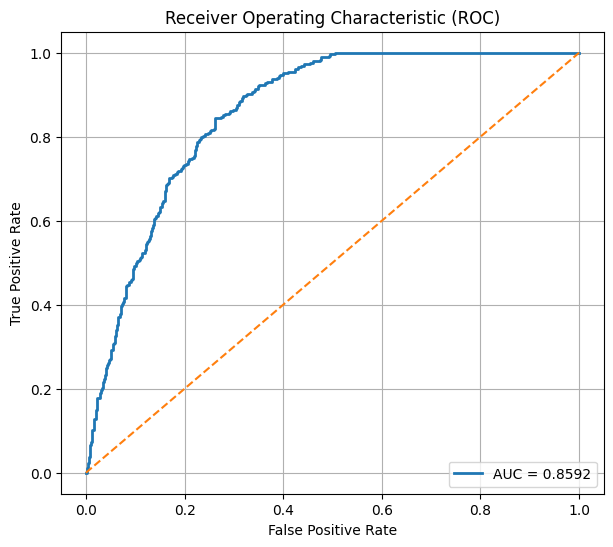

In [14]:
# ROC CURVE

fpr, tpr, thresholds = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend(loc="lower right")

plt.grid(True)

plt.show()

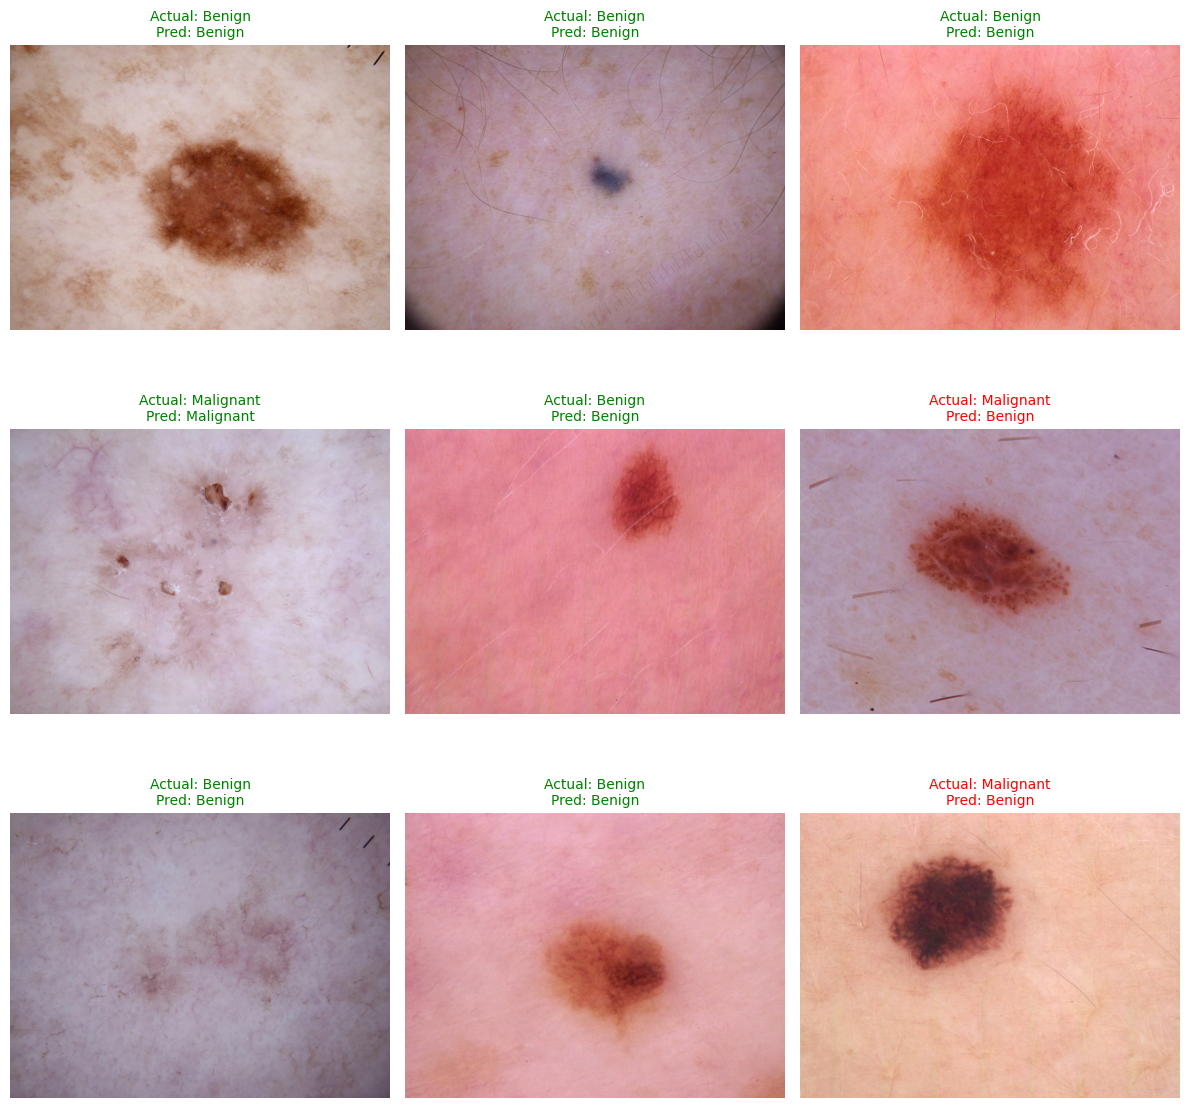

In [19]:
# SAMPLE TEST PREDICTIONS

import matplotlib.image as mpimg

num_images = 9

indices = np.random.choice(len(test_df), num_images, replace=False)

plt.figure(figsize=(12,12))

for i, idx in enumerate(indices):

    plt.subplot(3,3,i+1)

    img = mpimg.imread(test_df.iloc[idx]["filepath"])

    plt.imshow(img)
    plt.axis("off")

    actual = "Malignant" if y_true[idx] == 1 else "Benign"
    predicted = "Malignant" if y_pred[idx] == 1 else "Benign"

    color = "green" if y_true[idx] == y_pred[idx] else "red"

    plt.title(
        f"Actual: {actual}\nPred: {predicted}",
        color=color,
        fontsize=10
    )

plt.tight_layout()

plt.show()

In [16]:
# SAVE METRICS

metrics = {
    "Accuracy": float(accuracy),
    "Precision": float(precision),
    "Recall": float(recall),
    "F1 Score": float(f1),
    "AUC": float(auc_score)
}

with open(MODELS_DIR / "evaluation_metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)

print("Evaluation metrics saved successfully.")

Evaluation metrics saved successfully.
